# Improving Sensory Perception for Drive Satisfaction

Our chemical sensor has a serious deficiency in that it suggest the presence of fruit or poison at a distant without resolving how to reach the fruit or avoid the poison. To begin to see this, let's visualize how the sensory map is classified in terms of drives.

In [ ]:
from tree_world.visualize import make_sensory_grid
from tree_world.simulation import TreeWorld, TreeWorldConfig, SimpleSensor
from tree_world.models.drives import train_drive_classifier

config = TreeWorldConfig()
config.sensor_attenuation = 1e-2
world = TreeWorld.random_from_config(config)
sensor = SimpleSensor.from_config(config)
old_world = world

drive_classifier, drive_keys = train_drive_classifier(config, with_ids=False)

grid_locations, sensory_values = make_sensory_grid(config.grid_size, config.grid_extent // 2, world, sensor)

drive_values = drive_classifier(sensory_values)


Drive Embedding Classifier Loss (with fruit amount): 0.003105737967416644 MSE: 2.285160690007615e-06 Accuracy: 100.00%


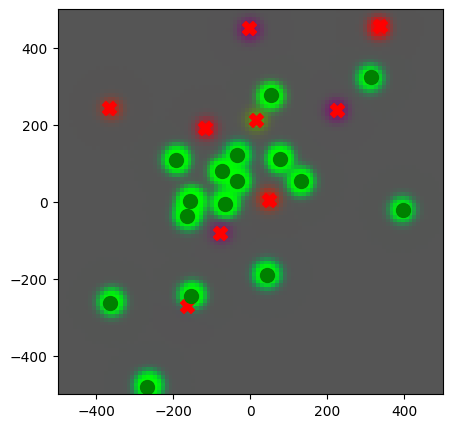

In [14]:
%matplotlib inline

import torch
from matplotlib import pyplot as plt


def plot_drive_values(world: TreeWorld, drive_values: torch.Tensor):
    extent = world.config.grid_extent / 2

    fig, ax = plt.subplots(figsize=(5,5))
    ax.imshow(
        drive_values.detach().cpu().numpy().reshape(config.grid_size, config.grid_size, 3).transpose(1, 0, 2),
        origin = 'lower',
        extent = [-extent, extent, -extent, extent]
    )

    for tree in world.trees:
        color = 'red' if tree.is_poisonous else 'green'
        marker = 'X' if tree.is_poisonous else 'o'
        ax.scatter(tree.location[0], tree.location[1], color=color, marker=marker, s=100)

    return fig, ax

drive_values = drive_values.view(config.grid_size, config.grid_size, 3).detach()
_ = plot_drive_values(old_world, drive_values)


For the most part, the map of drives make sense. But as we see, if there are poison trees near the edible fruit trees, the edible scent overwhelms the scent of the poison, leaving the unwary agent to consume poison where his senses fail to inform him.

Perhaps this is because our drive is classifying exclusively? Maybe if we allow "poison" and "edible" to be collocated in theory, then we can get a better map.

Drive Embedding Classifier Loss (with fruit amount): 0.028425049036741257 MSE: 0.3394714593887329 Accuracy: 16.67%


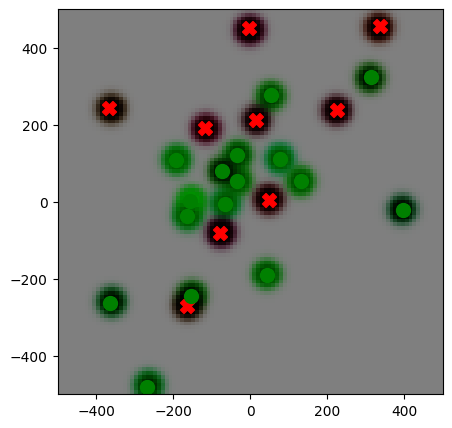

In [15]:
nonexclusive_drive_classifier, drive_keys = train_drive_classifier(config, with_ids=False, nonexclusive=True)

nonexclusive_drive_values = nonexclusive_drive_classifier(sensory_values)

_ = plot_drive_values(old_world, nonexclusive_drive_values)

Yes, this is a much better view. We should use this for our agents.

But this sensor still is giving us a static view.

After all, what we desire of the sensor is to tell us _where_ the fruit are, not when they are near. We are interested in cause and effect; the scent is an effect of the tree, so our sense should reveal the cause.

## Differential Sensors

Biological organisms do not typically have static senses. Instead, the sense are organized to detect change and movement. In terms of smell, our agent should be looking for concentration gradients. That is, differences in the percepts that indicate the direction towards a satisfying stimulus.

Let us represent our drives a set of motivations $m = (m_1, \ldots, m_D)$ where $D$ is the total number of drives and $m_i$ indicates the motivational value of a stimulus for satisfying drive $i$. Then we want to know the Jacobian of the motivations $m$ with respect to the locations $\ell = (\ell_1, \ldots \ell_J)$, which, via the chain rule, can be realized as the matrix product of two Jacobians by interposing the senses $x = (x_1, \dots x_M)$: 
$$
J_m(\ell) \,\,=\,\, \left[\begin{array}{ccc}
\frac{\partial m_1}{\partial\ell_1} &\ldots& \frac{\partial m_1}{\partial\ell_N}\\
\vdots & \ddots & \vdots \\
\frac{\partial m_D}{\partial\ell_1} &\ldots& \frac{\partial m_D}{\partial\ell_N}
\end{array}\right]
\quad=\quad
J_m(x) \,\,J_x(\ell)\quad=\quad\left[\begin{array}{ccc}
\frac{\partial m_1}{\partial x_1} &\ldots& \frac{\partial m_1}{\partial x_M}\\
\vdots & \ddots & \vdots \\
\frac{\partial m_D}{\partial x_1} &\ldots& \frac{\partial m_D}{\partial x_M}
\end{array}\right]\,\,\left[\begin{array}{ccc}
\frac{\partial x_1}{\partial ell_1} &\ldots& \frac{\partial x_1}{\partial\ell_N}\\
\vdots & \ddots & \vdots \\
\frac{\partial x_M}{\partial ell_1} &\ldots& \frac{\partial x_M}{\partial\ell_N}
\end{array}\right].
$$
We already have a drive classifier, which is an estimator for $m$, and we have an equation for our sensor. So we can compute this Jacobian, which is a $3 \times 2$ matrix, for each point on our $101 \times 101$ grid. We can then plot the results by motivation. 

In [16]:
# sum trick for computing jacobians in batches
def batch_jacobian(func, x, create_graph=False):
  # x in shape (Batch, Length)
  def _func_sum(x):
    return func(x).sum(dim=0)
  return torch.autograd.functional.jacobian(_func_sum, x, create_graph=create_graph).permute(1,0,2)



In [17]:
Jmx = batch_jacobian(drive_classifier, sensory_values)
print("Jmx shape", Jmx.shape)
sense_fn = lambda x: sensor.sense(old_world, x, None)[1]
Jxl = batch_jacobian(sense_fn, grid_locations)
print("Jxl shape", Jxl.shape)
Jml = Jmx @ Jxl
print("Jml shape", Jml.shape)


Jmx shape torch.Size([10201, 3, 1024])
Jxl shape torch.Size([10201, 1024, 2])
Jml shape torch.Size([10201, 3, 2])


(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': '∇m1'}>, <Axes: title={'center': '∇m2'}>],
       dtype=object))

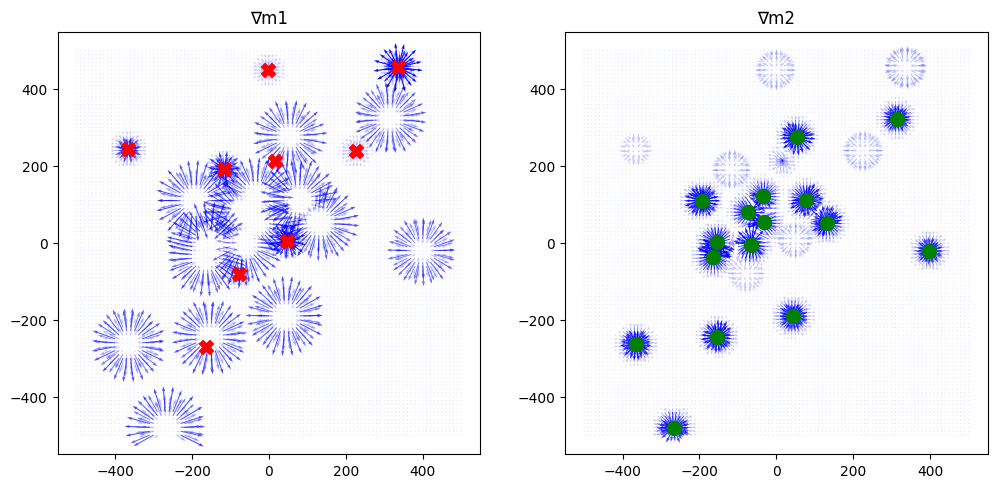

In [18]:
import matplotlib.pyplot as plt
import numpy as np


def plot_drive_jacobians(world: TreeWorld, Jml: torch.Tensor):
    xs = grid_locations[:,0].reshape(101, 101)
    ys = grid_locations[:,1].reshape(101, 101)

    # Jml: (10201, 3, 2)
    J = Jml.reshape(101, 101, 3, 2).detach().cpu().numpy()

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    titles = ["∇m1", "∇m2", "∇m3"]

    for i in range(2):
        U = J[:,:,i,0]   # ∂m_i/∂x
        V = J[:,:,i,1]   # ∂m_i/∂y

        # Signed magnitude or any scalar criterion
        S = U + V   # example sign function (choose what you want)
        
        mag = np.sqrt(U**2 + V**2)
        alpha = np.clip(mag / mag.max(), 0.2, 1.0)

        orange = np.array([1,0.5,0])[None,None,:].repeat(101, axis=0).repeat(101, axis=1)
        orange = np.concatenate([orange, alpha[:,:,None]], axis=-1)
        purple = np.array([0,0,1])[None,None,:].repeat(101, axis=0).repeat(101, axis=1)
        purple = np.concatenate([purple, alpha[:,:,None]], axis=-1)

        S = S[:,:, None]
        colors = purple # np.where(S > 0, purple, orange)

        axs[i].quiver(xs, ys, U, V, angles='xy', color=colors.reshape(-1, 4))
        axs[i].set_title(titles[i])
        axs[i].set_aspect('equal')

    for tree in world.trees:
        color = 'red' if tree.is_poisonous else 'green'
        marker = 'X' if tree.is_poisonous else 'o'

        i = 0 if tree.is_poisonous else 1
        axs[i].scatter(tree.location[0], tree.location[1], color=color, marker=marker, s=100)
    
    return fig, axs

plot_drive_jacobians(old_world, Jml)


So our Jacobian tells us which direction to travel if we want to find edible fruit or poison. However, it is skewed by the mutual exclusivity of the drives and doesn't do a great job around the poison trees.

Jmx shape torch.Size([10201, 3, 1024])
Jxl shape torch.Size([10201, 1024, 2])
Jml shape torch.Size([10201, 3, 2])


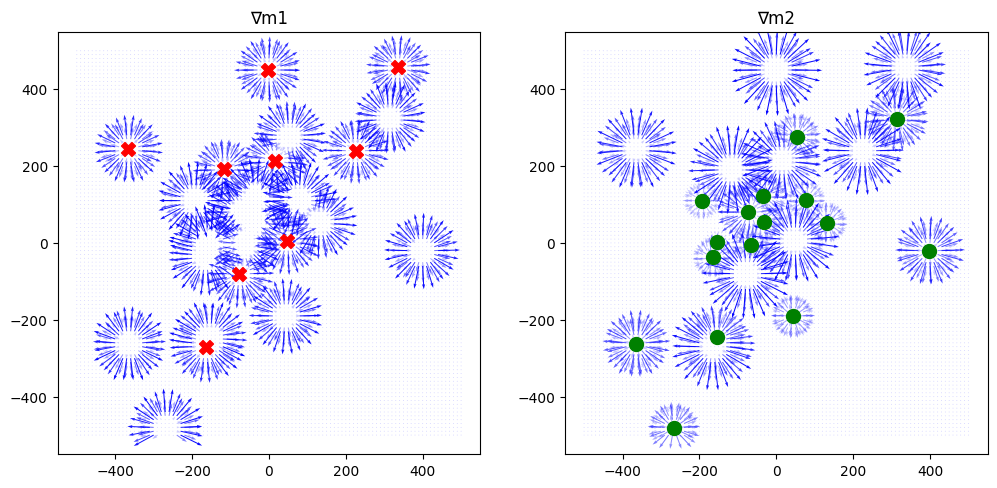

In [19]:
xJmx = batch_jacobian(nonexclusive_drive_classifier, sensory_values)
print("Jmx shape", Jmx.shape)
sense_fn = lambda x: sensor.sense(old_world, x, None)[1]
xJxl = batch_jacobian(sense_fn, grid_locations)
print("Jxl shape", Jxl.shape)
xJml = xJmx @ xJxl
print("Jml shape", Jml.shape)

_ = plot_drive_jacobians(old_world, xJml)

We still see the shadowing effect on the poison trees, even though the nonexclusive drives do a better job of pointing the way to individual edible fruit trees. 

In part, this is due to saturation around the edible fruit; when the trees are clustered together, the sensor maxes out and can't find the trees with any precision. We might want to use multiple resolution scales (`config.sensor_attenuation`) on our sensor.


## Remembering the Rewards to Interpret the Senses

We've put a lot of energy into remembering the sensory data. But what about the rewards? We can detect when we have satisfied a drive, and we can remember where it happened.

Once we have a map from locations to rewards, then we can compute the distance from any point to the closest point where a reward was received. Thus, the agent can always know when it is close to a reward received once before. 

Now, recall that our map is a regression function from from locations to sensations, $f : \ell \mapsto x$. Once the agent remembers where rewards were received, the map plus the reward memory gives us a dataset $\{(x_i, r_i)\}$ mediated by locations. From this we could learn a function $x \mapsto r$. 

However, we can do more. Let us define a "cost-to-go" $C(\ell, \delta\ell, m)$ representing the shortest distance from position $\ell$ to some location containing a satisfier for drive $m$ in direction $\delta \ell$. Given a location $\ell^*_i$ from the memory providing a reward $r^*_i$ and any other location $\ell$, we obtain an upper bound 
$$C(\ell, \ell^*_i - \ell, r^*_i) \,\,\leq\,\, \|\ell - \ell^*_i\|$$
that tells us how far it is to the nearest reward from $\ell$ in the direction $\ell^*_i - \ell$. We would like the agent to estimate $C$ in each direction at each time point, and it can easily do so using the reward memory, up to the limits of its experience.

But the learning of reward locations is not portable between sessions; at the start of a session, the agent can only engage in trial and error to learn. However, the sense values indicate the reward location, and these _are_ portable between simulations. What we can do is learn a function
$$
\hat{C}(x, \delta\ell, m) \overset{>}{\approx} C(\ell, \delta\ell, m),
$$
that can be reused to extract reward locations from the senses, training it from tuples
$$
\left(\vphantom{x^{x^{x^{x^x}}}}\left(\vphantom{x^{x^x}} f(\ell), \ell^*_i, r^*_i\right),\, \|\ell - \ell^*_i\|\right)
$$
where $(\ell^*_i, r^*_i)$ are reward locations in the memory, $\ell$ is a location reasonably in the vicinity of $\ell^*i$, that is, within `config.max_sense_distance` or some fraction thereof. Here $x=f(\ell)$ is an estimate of the senses at location $\ell$ from our map. Ideally, $\ell$ would be a memory point in the map, so that $x$ is exact, not estimated.

We just need to modify our agent to remember the locations where rewards were received, and then periodically train a regression for $\hat{C}$. Then we can use this function to build our local exploitation map.



In [20]:
import torch

class SensoryCostToGoRegressor(torch.nn.Module):
    def __init__(self, sensory_embedding_dim: int, location_dim: int, drive_dim: int, hidden_dim: int=128, scale=25.0):
        super().__init__()
        self.scale = scale

        self.fc1 = torch.nn.Linear(sensory_embedding_dim + location_dim + drive_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = torch.nn.Linear(hidden_dim, 1)

    def forward(self, sensory_embedding: torch.Tensor, location: torch.Tensor, drive: torch.Tensor):
        x = torch.cat([sensory_embedding, location, drive], dim=1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x) * self.scale

In [21]:
from tree_world.drive_agents import DriveBasedAgentWithMemory
from tree_world.models.memory import SpatialMemory
from tree_world.states import DriveManager, Location


class DriveBasedAgentWithRewardMemory(DriveBasedAgentWithMemory):
    def __init__(self, 
        sensory_embedding_dim: int, 
        sensory_embedding_model: str, 
        dim: int=2, 
        can_see_fruit_distance: float=10.0, 
        max_distance: float=100.0,
        memory: SpatialMemory=None,
        drive_manager: DriveManager=None,
        reward_memory: SpatialMemory=None,
    ):
        super().__init__(
            sensory_embedding_dim, 
            sensory_embedding_model, 
            dim, 
            can_see_fruit_distance, 
            max_distance, 
            memory,
            drive_manager,
        )

        drive_dim = 2
        if reward_memory is None:
            reward_memory = SpatialMemory(
                dim, 
                drive_dim, 
                drive_dim
            )

        self.reward_memory = reward_memory

        self.cost_to_go_regressor = SensoryCostToGoRegressor(
            sensory_embedding_dim, 
            dim, 
            drive_dim, 
            hidden_dim=128
        )

        self.optimizer = torch.optim.AdamW(self.cost_to_go_regressor.parameters(), lr=0.001)

        self.cycles_per_training = 100

        self.old_samples = None
    
    def reset(self):
        super().reset()
        
        # capture the data
        if self.reward_memory.memory_size() == 0:
            return

        all_senses = []
        all_locations_deltas = []
        all_drive_states = []
        all_distances = []
        for _ in range(100):
            (senses, locations_deltas, drive_states), distances = self.get_data_sample()
            all_senses.append(senses)
            all_locations_deltas.append(locations_deltas)
            all_drive_states.append(drive_states)
            all_distances.append(distances)

        all_senses = torch.cat(all_senses, dim=0)
        all_locations_deltas = torch.cat(all_locations_deltas, dim=0)
        all_drive_states = torch.cat(all_drive_states, dim=0)
        all_distances = torch.cat(all_distances, dim=0)

        if self.old_samples is None:
            self.old_samples = (all_senses, all_locations_deltas, all_drive_states, all_distances)
        else:
            self.old_samples = (
                torch.cat([self.old_samples[0], all_senses], dim=0),
                torch.cat([self.old_samples[1], all_locations_deltas], dim=0),
                torch.cat([self.old_samples[2], all_drive_states], dim=0),
                torch.cat([self.old_samples[3], all_distances], dim=0)
            )
        
        self.reward_memory.reset()
    
    def update_rewards(self, reward: float, agent_location: Location=None):
        super().update_rewards(reward, agent_location)
        if reward != 0.0:
            drive_state = torch.tensor([0,0])
            if reward < 0.0:
                drive_state[0] = 1
            else:
                drive_state[1] = 1

            self.reward_memory.write(agent_location.location[None,:], agent_location.location_sd[None,:], drive_state[None,:])

    def get_data_sample(self, batch_size: int=100):
        locations = self.reward_memory.memory_locations
        rewards = self.reward_memory.memory_senses.squeeze(0)
        other_locations = locations + torch.randn_like(locations) * self.can_see_fruit_distance
        locations_deltas = (locations - other_locations).squeeze(0)
        distances = torch.norm(locations_deltas, dim=-1)
        locations_deltas = locations_deltas / distances[:, None]
        senses = self.memory.read(other_locations, torch.ones_like(other_locations), match_threshold=25.0).squeeze(0)

        if self.old_samples is not None:
            senses = torch.cat([self.old_samples[0], senses], dim=0)
            locations_deltas = torch.cat([self.old_samples[1], locations_deltas], dim=0)
            rewards = torch.cat([self.old_samples[2], rewards], dim=0)
            distances = torch.cat([self.old_samples[3], distances], dim=0)

        # TODO: permute and truncate
        perm = torch.randperm(senses.shape[0])
        senses = senses[perm[:batch_size]]
        locations_deltas = locations_deltas[perm[:batch_size]]
        rewards = rewards[perm[:batch_size]]
        distances = distances[perm[:batch_size]]
        
        return (senses, locations_deltas, rewards), distances
    
    def train(self):
        if self.reward_memory.memory_size() == 0:
            return

        for i in range(self.cycles_per_training):
            (senses, locations_deltas, drive_states), distances = self.get_data_sample()
            cost_to_go_estimates = self.cost_to_go_regressor(senses, locations_deltas, drive_states)
            loss = torch.nn.functional.mse_loss(cost_to_go_estimates, distances)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

        print(f"Cost-to-go regressor training cycle complete with loss {torch.sqrt(loss).item()}")

        super().train()  # <-- this will prune the sensory memory. Do we want this last?
        

Now we are ready to run a simulation or two to learn a regressor.

In [22]:
config.model_type = 'DriveBasedAgentWithRewardMemory'

world = TreeWorld.random_from_config(config)

Drive Embedding Classifier Loss (with fruit amount): 0.003123142523691058 MSE: 1.107883235818008e-05 Accuracy: 100.00%


In [23]:
def run_simulation(world: TreeWorld, steps: int=1000, record: bool=False):
    world.randomize()

    print(f"Running tree world for {steps} steps...")
    world.run(steps, record=record)
    print()
    print("Tree world run complete.")

    print(f"Agent health: {world.agent.health}")
    print(f"Agent fruit eaten: {world.agent.fruit_eaten}")
    print(f"Agent poisonous fruit eaten: {world.agent.poisonous_fruit_eaten}")
    print(f"Agent total movement: {world.agent.total_movement}")
    print(f"Agent final location: {torch.norm(world.agent.location).item()}")

In [24]:
# for i in range(10):
#     run_simulation(world)